# Customer Churn Analysis

## Objective
The goal of this project is to analyze customer behavior and identify key factors contributing to customer churn.

We will:
- Explore multiple data sources (demographics, transactions, service, online activity)
- Perform data cleaning and feature engineering
- Identify patterns related to churn
- Prepare a dataset suitable for predictive modeling

## Dataset Overview
The dataset consists of 5 tables:

1. Customer_Demographics → Customer personal details
2. Transaction_History → Customer financial transactions
3. Customer_Service → Complaints and service interactions
4. Online_Activity → Digital engagement data
5. Churn_Status → Target variable (whether customer churned or not)

## 1. Import Libraries & Configuration

In [1]:
# Libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

# Configurations
sns.set_style('darkgrid')

## 2. Load Dataset

In [2]:
# Define dataset path
file_path = "../data/Customer_Churn_Data_Large.xlsx"
data = pd.ExcelFile(file_path)

# Load each dataset from Excel sheets
customer_demographics = pd.read_excel(file_path, sheet_name= "Customer_Demographics")
transaction_history = pd.read_excel(file_path, sheet_name= "Transaction_History")
customer_service = pd.read_excel(file_path, sheet_name= "Customer_Service")
online_activity = pd.read_excel(file_path, sheet_name= "Online_Activity")
churn_status = pd.read_excel(file_path, sheet_name= "Churn_Status")

# Check sheet lists
print(f"Total datasets in this file - {data.sheet_names}")

Total datasets in this file - ['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


## 3. Exploratory Data Analysis (EDA)

As the Customer_Churn_Data_Large.xlsx file consists of five separate tables - **Customer_Demographics, Transaction_History, Customer_Service, Online_Activity, and Churn_Status**. We will first perform initial inspection and exploratory data analysis (EDA) on each dataset individually to understand their structure, distributions, and key patterns.

After completing the individual dataset analysis, all datasets will be merged into a single dataset for final exploratory data analysis and churn-focused insights.

In [3]:
# Define inspect fucntion for quick data inspection
def inspect(df, name):
    print(f"\n{name}")
    print("-"*40)

    print("Sample Records:")
    print(df.head())
    
    print("\nShape:")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    
    print("\nData Info:")
    df.info()
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print(f"\nDuplicated Rows: {df.duplicated().sum()}")
    
    print("\nStatistical Summary:")
    print(df.describe())
    print("\n")



#### Dataset 1 - Customer Demographics :

In [4]:
inspect(customer_demographics, "Customer Demographics")


Customer Demographics
----------------------------------------
Sample Records:
   CustomerID  Age Gender MaritalStatus IncomeLevel
0           1   62      M        Single         Low
1           2   65      M       Married         Low
2           3   18      M        Single         Low
3           4   21      M       Widowed         Low
4           5   21      M      Divorced      Medium

Shape:
Rows: 1000, Columns: 5

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     1000 non-null   int64
 1   Age            1000 non-null   int64
 2   Gender         1000 non-null   str  
 3   MaritalStatus  1000 non-null   str  
 4   IncomeLevel    1000 non-null   str  
dtypes: int64(2), str(3)
memory usage: 39.2 KB

Missing Values:
CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64

Dupl

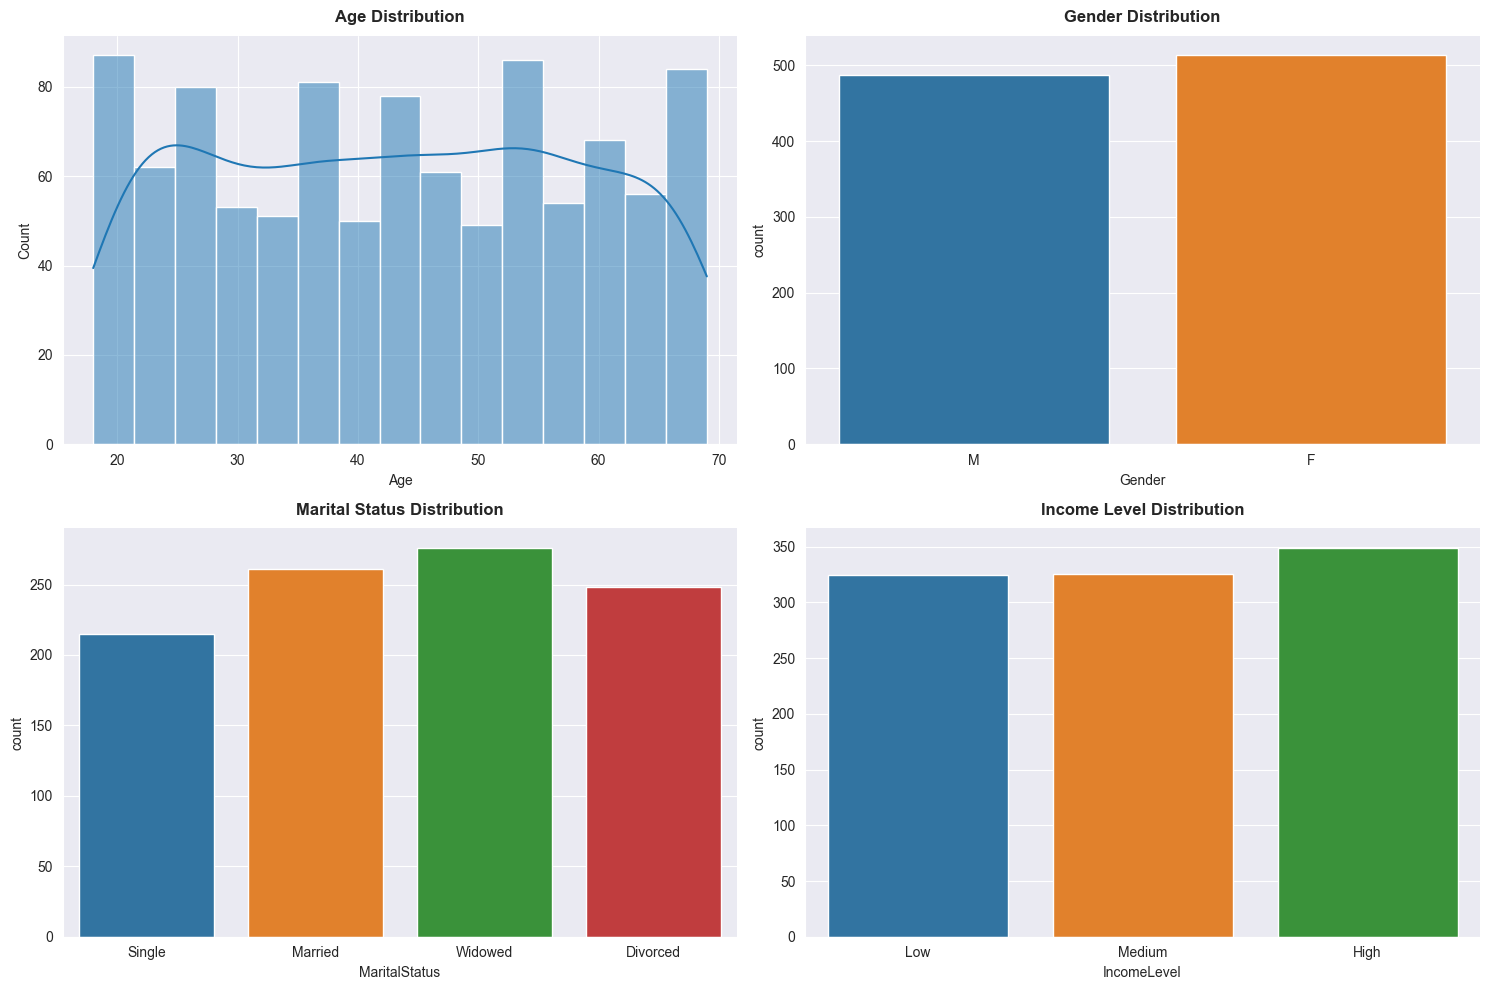

In [5]:
# Define figure size
plt.figure(figsize=(15,10))

# Age Distribution
plt.subplot(2,2,1)
sns.histplot(data=customer_demographics, x='Age',bins=15, kde=True)
plt.title('Age Distribution', fontweight='bold',pad=10)
sns.despine()

# Gender Distribution
plt.subplot(2,2,2)
sns.countplot(data=customer_demographics, x='Gender',palette='tab10')
plt.title('Gender Distribution', fontweight='bold',pad=10)
sns.despine()

# Marital Status Distribution
plt.subplot(2,2,3)
sns.countplot(data=customer_demographics, x='MaritalStatus',palette='tab10')
plt.title('Marital Status Distribution', fontweight='bold',pad=10)
sns.despine()

# Income Level Distribution
plt.subplot(2,2,4)
sns.countplot(data=customer_demographics, x='IncomeLevel',palette='tab10')
plt.title('Income Level Distribution', fontweight='bold',pad=10)
sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Customer_Demographics_overview.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Observations :
- There are 1000 rows and 5 columns in this dataset.
- The dataset contains no missing or duplicate values.
- Customer ages are distributed fairly evenly between 18 and 69 years, with an average age of approximately 43 years.
- In Gender, number of female customers are slightly higher compared to male customers.
- Widowed customers are slightly higher in number compared to other marital status categories.
- Income levels are also fairly balanced among Low, Medium, and High categories, with High income customers slightly dominating the dataset.
- No major skewness or abnormal patterns are visible in demographic features at the initial exploration stage.

#### Dataset 2 - Transaction History :

In [6]:
inspect(transaction_history, "Transaction History")


Transaction History
----------------------------------------
Sample Records:
   CustomerID  TransactionID TransactionDate  AmountSpent ProductCategory
0           1           7194      2022-03-27       416.50     Electronics
1           2           7250      2022-08-08        54.96        Clothing
2           2           9660      2022-07-25       197.50     Electronics
3           2           2998      2022-01-25       101.31       Furniture
4           2           1228      2022-07-24       397.37        Clothing

Shape:
Rows: 5054, Columns: 5

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 5054 entries, 0 to 5053
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       5054 non-null   int64         
 1   TransactionID    5054 non-null   int64         
 2   TransactionDate  5054 non-null   datetime64[us]
 3   AmountSpent      5054 non-null   float64       
 4   ProductCategory  

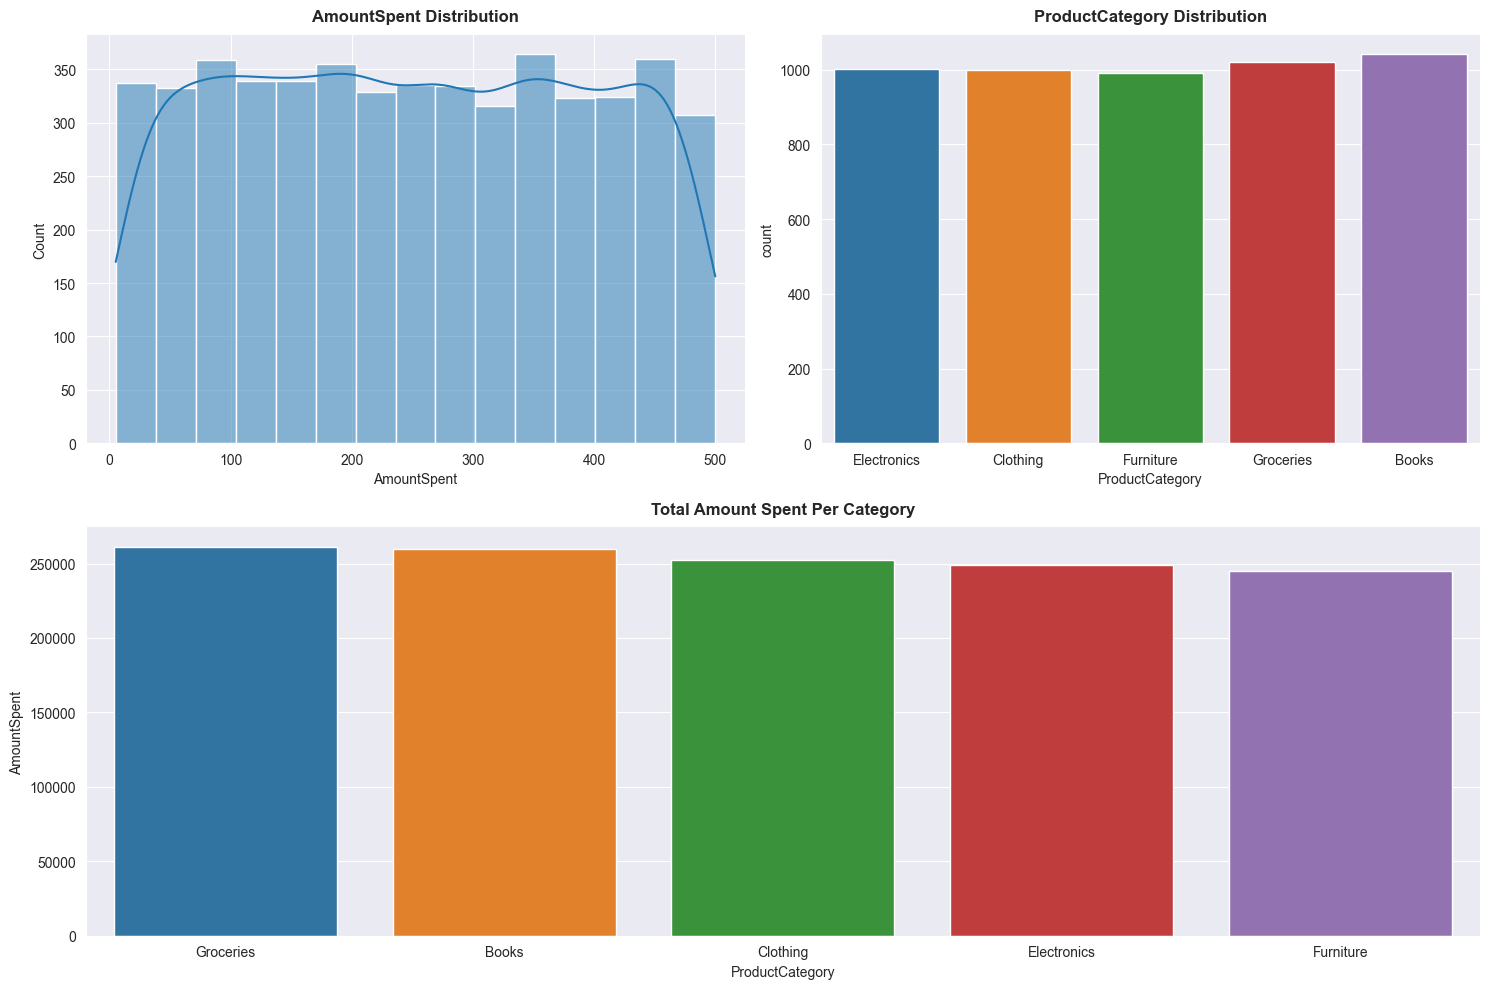

  ProductCategory  AmountSpent
0       Groceries    261133.65
1           Books    259564.99
2        Clothing    252450.70
3     Electronics    249139.79
4       Furniture    244785.82


In [7]:
plt.figure(figsize=(15,10))

# Amount Spent Distribution
plt.subplot(2,2,1)
sns.histplot(data=transaction_history,x='AmountSpent',bins=15,kde=True,palette='tab10')
plt.title('AmountSpent Distribution', fontweight='bold',pad=10)
sns.despine()

# Product Category Distribution
plt.subplot(2,2,2)
sns.countplot(data=transaction_history, x='ProductCategory',palette='tab10')
plt.title('ProductCategory Distribution', fontweight='bold',pad=10)
sns.despine()

# Aggregation
amount_per_category = (
    transaction_history.groupby('ProductCategory')['AmountSpent'].sum().sort_values(ascending=False).reset_index()
)

#  Amount Spent Per Category
plt.subplot(2,1,2)
sns.barplot(data=amount_per_category, x='ProductCategory', y='AmountSpent',palette='tab10')
plt.title('Total Amount Spent Per Category', fontweight='bold',pad=10)
sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Transaction_History_overview.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(amount_per_category)

#### Observations :
- Total customers are 1000 and this dataset contains 5054 records, indicating multiple transactions per customer.
- No missing or duplicate values are present in the dataset.
- Transaction amounts range from approximately 5 to 500, with an average transaction value around 251.
- Mean and median transaction amounts are nearly identical, suggesting a balanced distribution with no major skewness or extreme outliers.
- Product categories are fairly evenly distributed in terms of transaction frequency.
- Total spending across product categories is also relatively balanced, with Groceries and Books contributing slightly higher overall spending compared to other categories.
- Transaction records span the complete year of 2022, enabling future time-based transaction analysis.

#### Dataset 3 - Customer Service :

In [8]:
inspect(customer_service, "Customer Service")


Customer Service
----------------------------------------
Sample Records:
   CustomerID  InteractionID InteractionDate InteractionType ResolutionStatus
0           1           6363      2022-03-31         Inquiry         Resolved
1           2           3329      2022-03-17         Inquiry         Resolved
2           3           9976      2022-08-24         Inquiry         Resolved
3           4           7354      2022-11-18         Inquiry         Resolved
4           4           5393      2022-07-03         Inquiry       Unresolved

Shape:
Rows: 1002, Columns: 5

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        1002 non-null   int64         
 1   InteractionID     1002 non-null   int64         
 2   InteractionDate   1002 non-null   datetime64[us]
 3   InteractionType   1002 non-null   str       

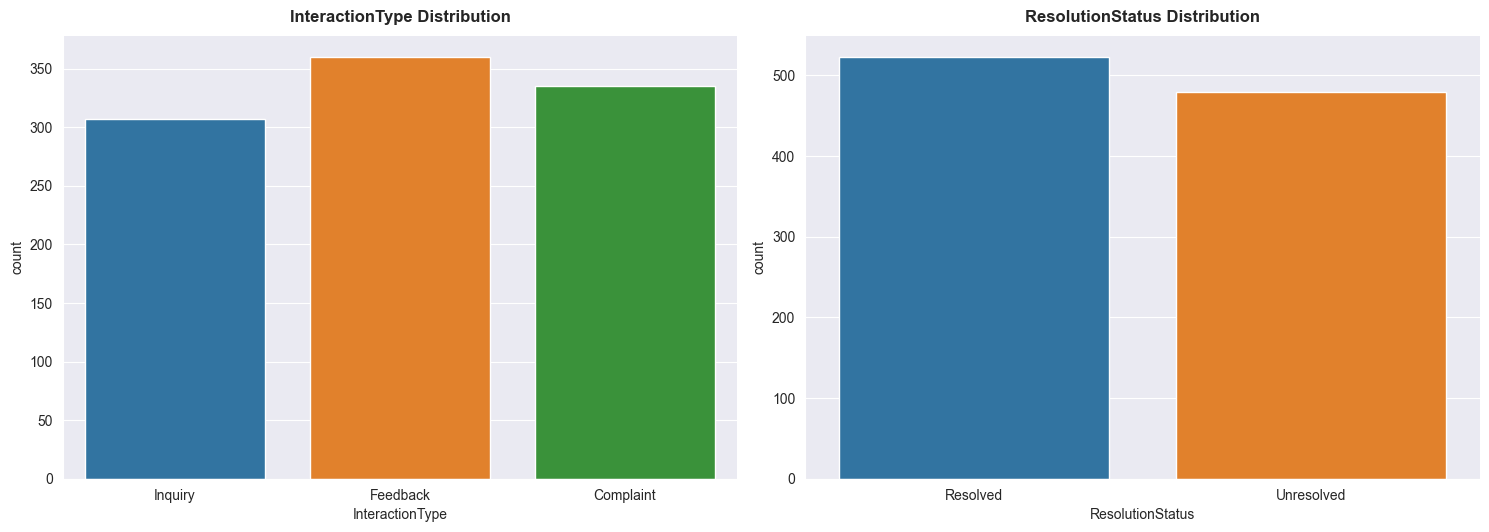

In [9]:
plt.figure(figsize=(15,10))

# Interaction Type Distribution
plt.subplot(2,2,1)
sns.countplot(data=customer_service,x='InteractionType',palette='tab10')
plt.title('InteractionType Distribution', fontweight='bold',pad=10)
sns.despine()

# Resolution Status Distribution
plt.subplot(2,2,2)
sns.countplot(data=customer_service, x='ResolutionStatus',palette='tab10')
plt.title('ResolutionStatus Distribution', fontweight='bold',pad=10)
sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Customer_Service_overview.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Observations:
- The dataset contains 1002 customer service interaction records across 1000 customers, indicating some customers had multiple service interactions.
- No missing or duplicate values are present in the dataset.
- Interaction records are fairly distributed across Inquiry, Feedback, and Complaint categories, with Feedback interactions appearing slightly more frequent.
- Resolved interactions are slightly higher than unresolved interactions, suggesting that most customer service requests are successfully handled.

#### Dataset 4 - Online Activity :

In [10]:
inspect(online_activity, "Online Activity")


Online Activity
----------------------------------------
Sample Records:
   CustomerID LastLoginDate  LoginFrequency ServiceUsage
0           1    2023-10-21              34   Mobile App
1           2    2023-12-05               5      Website
2           3    2023-11-15               3      Website
3           4    2023-08-25               2      Website
4           5    2023-10-27              41      Website

Shape:
Rows: 1000, Columns: 4

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CustomerID      1000 non-null   int64         
 1   LastLoginDate   1000 non-null   datetime64[us]
 2   LoginFrequency  1000 non-null   int64         
 3   ServiceUsage    1000 non-null   str           
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 31.4 KB

Missing Values:
CustomerID        0
LastLoginDate     0
LoginFrequen

In [11]:
# Check total ServiceUsage categories
service_category = online_activity['ServiceUsage'].value_counts()
service_category


ServiceUsage
Online Banking    349
Mobile App        342
Website           309
Name: count, dtype: int64

In [12]:
# Check total LoginFrequency per ServiceUsage category
total_login_frequency = online_activity.groupby('ServiceUsage')['LoginFrequency'].sum().reset_index()
total_login_frequency

,ServiceUsage,LoginFrequency
0,Mobile App,8565
1,Online Banking,9375
2,Website,7972


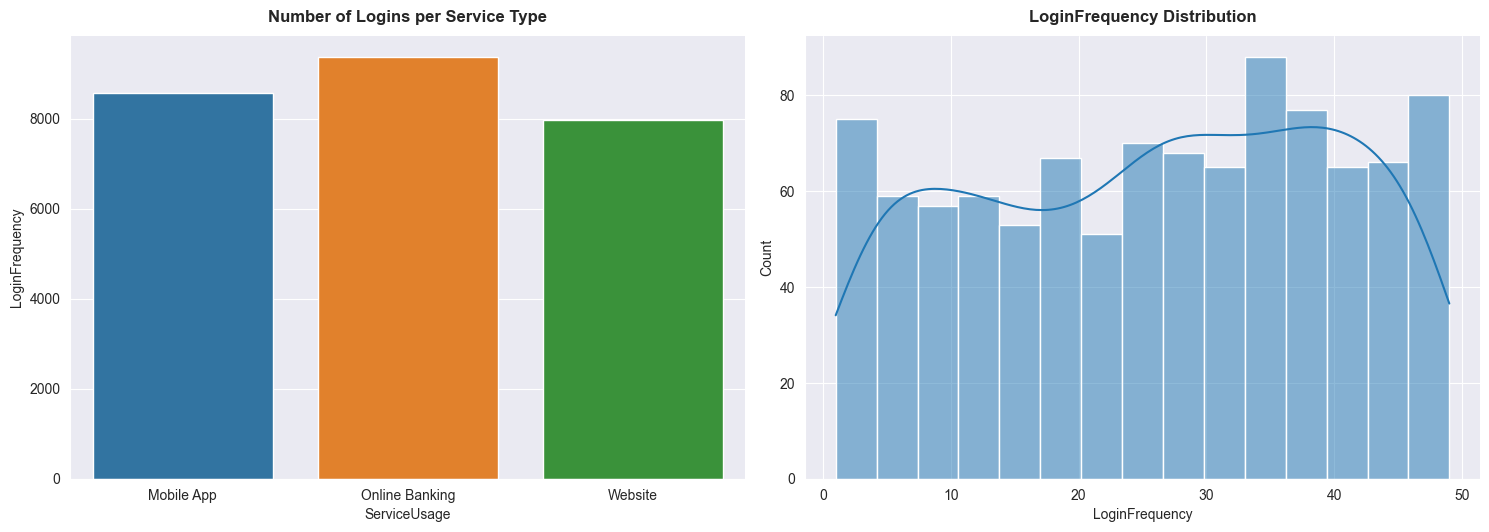

In [13]:
plt.figure(figsize=(15,10))

# LoginFrequency per ServiceUsage Distribution
plt.subplot(2,2,1)
sns.barplot(data=total_login_frequency,x='ServiceUsage', y='LoginFrequency', palette= 'tab10')
plt.title("Number of Logins per Service Type",fontweight='bold',pad=10)
sns.despine()

# LoginFrequency Distribution
plt.subplot(2,2,2)
sns.histplot(data=online_activity, x='LoginFrequency',bins=15,kde=True)
plt.title('LoginFrequency Distribution', fontweight='bold',pad=10)
sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Online_Activity_overview.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Observations:
- The Online Activity dataset contains 1000 records and 4 columns, with no missing or duplicate values.
- Login frequency ranges from 1 to 49, with an average of approximately 26 logins per customer..
- Service usage is relatively balanced across all three digital channels:
  - Online Banking: 349 customers
  - Mobile App: 342 customers
  - Website: 309 customers
- Online Banking records the highest total login frequency (9375), followed by Mobile App (8565) and Website (7972), indicating slightly higher overall engagement on the online banking platform.
- The distribution of login frequency appears reasonably uniform

#### Dataset 5 - Churn Status :

In [14]:
inspect(churn_status, "Churn Status")


Churn Status
----------------------------------------
Sample Records:
   CustomerID  ChurnStatus
0           1            0
1           2            1
2           3            0
3           4            0
4           5            0

Shape:
Rows: 1000, Columns: 2

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   CustomerID   1000 non-null   int64
 1   ChurnStatus  1000 non-null   int64
dtypes: int64(2)
memory usage: 15.8 KB

Missing Values:
CustomerID     0
ChurnStatus    0
dtype: int64

Duplicated Rows: 0

Statistical Summary:
        CustomerID  ChurnStatus
count  1000.000000  1000.000000
mean    500.500000     0.204000
std     288.819436     0.403171
min       1.000000     0.000000
25%     250.750000     0.000000
50%     500.500000     0.000000
75%     750.250000     0.000000
max    1000.000000     1.000000




In [15]:
# Map numeric labels (0 and 1) to readable labels (No Churn and Churn)
churn_labels = (
    churn_status['ChurnStatus']
    .map({0: 'No Churn', 1: 'Churn'})
)
churn_labels.value_counts()

ChurnStatus
No Churn    796
Churn       204
Name: count, dtype: int64

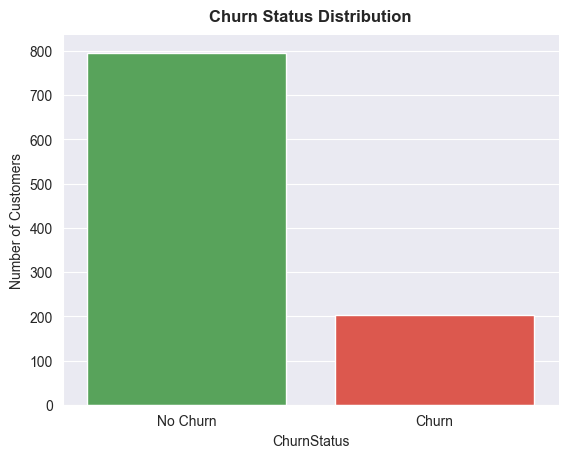

In [16]:
# ChurnStatus Distribution
sns.countplot(
    x=churn_labels,
    palette=['#4CAF50', '#F44336']
)
plt.title('Churn Status Distribution', fontweight='bold', pad=10)
plt.ylabel('Number of Customers')
sns.despine()

# Save figure
plt.savefig(
    '../plots/Chrun_Status_overview.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Observations:
- The Churn Status dataset contains 1000 customer records and 2 columns, with no missing or duplicate values.
- Out of 1000 customers:
  - 796 customers did not churn.
  - 204 customers churned.
- The dataset shows a moderate class imbalance, with non-churned customers higher then churned customers.


## 4. Creating the Final Customer-Level Dataset

To build a predictive model for customer churn, all source tables must be consolidated into a single customer-level dataset. Since some datasets contain multiple records per customer (such as transaction history and customer service interactions), they are first aggregated to generate summary features. These aggregated datasets are then merged with customer demographics, online activity, and churn status to create one final dataset with one row per customer.

### Merge Datasets 

In [17]:
# Merge all datasets in a single dataset
merge_df = (
    customer_demographics.merge(transaction_history,on='CustomerID',how='left')
                         .merge(customer_service,on='CustomerID',how='left')
                         .merge(online_activity,on='CustomerID',how='left')
                         .merge(churn_status,on='CustomerID',how='left')
)
merge_df

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363.0,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,1000,34,M,Widowed,Low,2724,2022-09-08,232.06,Groceries,NaN,NaT,NaN,NaN,2023-08-13,22,Mobile App,0
6808,1000,34,M,Widowed,Low,2917,2022-12-13,324.98,Books,NaN,NaT,NaN,NaN,2023-08-13,22,Mobile App,0
6809,1000,34,M,Widowed,Low,2979,2022-06-15,375.34,Groceries,NaN,NaT,NaN,NaN,2023-08-13,22,Mobile App,0
6810,1000,34,M,Widowed,Low,8594,2022-04-08,166.73,Books,NaN,NaT,NaN,NaN,2023-08-13,22,Mobile App,0


In [18]:
# Shape of dataset 
print("Rows:",merge_df.shape[0])
print("Columns:",merge_df.shape[1])

Rows: 6812
Columns: 17


In [19]:
# Total number of unique customer id
print("Unique customers:", merge_df['CustomerID'].nunique())

Unique customers: 1000


In [20]:
# Check missing values 
print("\nMissing Values:")
merge_df.isnull().sum()


Missing Values:


CustomerID             0
Age                    0
Gender                 0
MaritalStatus          0
IncomeLevel            0
TransactionID          0
TransactionDate        0
AmountSpent            0
ProductCategory        0
InteractionID       1608
InteractionDate     1608
InteractionType     1608
ResolutionStatus    1608
LastLoginDate          0
LoginFrequency         0
ServiceUsage           0
ChurnStatus            0
dtype: int64

In [21]:
# Check transaction_history sample records
print(transaction_history.head(10))

   CustomerID  TransactionID TransactionDate  AmountSpent ProductCategory
0           1           7194      2022-03-27       416.50     Electronics
1           2           7250      2022-08-08        54.96        Clothing
2           2           9660      2022-07-25       197.50     Electronics
3           2           2998      2022-01-25       101.31       Furniture
4           2           1228      2022-07-24       397.37        Clothing
5           2           8903      2022-01-09       285.21     Electronics
6           2           3527      2022-09-16       311.34     Electronics
7           2           9279      2022-11-19       199.73       Groceries
8           3           9839      2022-10-08       241.06           Books
9           3           7364      2022-08-15        51.07        Clothing


In [22]:
# Check customer_service sample records
print(customer_service.head(10))

   CustomerID  InteractionID InteractionDate InteractionType ResolutionStatus
0           1           6363      2022-03-31         Inquiry         Resolved
1           2           3329      2022-03-17         Inquiry         Resolved
2           3           9976      2022-08-24         Inquiry         Resolved
3           4           7354      2022-11-18         Inquiry         Resolved
4           4           5393      2022-07-03         Inquiry       Unresolved
5           6           2358      2022-05-05        Feedback         Resolved
6           8           4191      2022-04-29         Inquiry       Unresolved
7           8           8937      2022-09-13        Feedback       Unresolved
8           9           7813      2022-08-15         Inquiry         Resolved
9          11           6610      2022-10-28        Feedback         Resolved


#### Observations:
- A direct merge of all datasets produced 6812 rows, while the base customer dataset contains only 1000 unique customers.
- This confirms that some datasets contain multiple records per customer, resulting in duplicated customer entries after merging.
- Transaction History and Customer Service are one-to-many tables and must be aggregated to customer level before merging.
- Service related columns contain missing values because many customers did not have any customer service interactions.
- To prepare the data for machine learning, all datasets must be transformed into a single customer-level dataset with one row per customer.

### Aggregate Transaction History Data

The Transaction History dataset contains multiple transaction records for each customer. To convert it into customer-level data, transaction records were aggregated to create summary features representing each customer's purchasing behavior.

In [23]:
# Aggregate transaction history
transaction_agg = (
    transaction_history
    .groupby('CustomerID')
    .agg(
        NumTransactions=('TransactionID', 'count'),
        TotalAmountSpent=('AmountSpent', 'sum'),
        AvgTransactionAmount=('AmountSpent', 'mean')
    )
    .reset_index()
)

In [24]:
# Check transaction_agg
transaction_agg.head()

,CustomerID,NumTransactions,TotalAmountSpent,AvgTransactionAmount
0,1,1,416.50,416.50000
1,2,7,1547.42,221.06000
2,3,6,1702.98,283.83000
3,4,5,917.29,183.45800
4,5,8,2001.49,250.18625


In [25]:
# Check shape 
transaction_agg.shape

(1000, 4)

### Aggregate Customer Service Data

The Customer Service dataset contains multiple interaction records for some customers. To convert it into customer-level data, service interactions were aggregated to create summary features representing each customer's support experience, including the total number of service interactions and the number of unresolved issues.

In [26]:
service_agg = (
    customer_service
    .groupby('CustomerID')
    .agg(
        NumServiceInteractions=('InteractionID', 'count'),
        NumUnresolvedIssues=('ResolutionStatus',lambda x: (x == 'Unresolved').sum())
    )
    .reset_index()
)

service_agg.head()

,CustomerID,NumServiceInteractions,NumUnresolvedIssues
0,1,1,0
1,2,1,0
2,3,1,0
3,4,2,1
4,6,1,0


In [27]:
# Check shape
service_agg.shape

(668, 3)

### Merge All Datasets

After aggregating the transaction history and customer service tables to customer level, all datasets were merged using `CustomerID` as the common key. The resulting dataset contains one row per customer and combines demographic, transactional, service, online activity, and churn information.

In [28]:
# Merge all datasets in a single dataset
final_df = (
    customer_demographics
    .merge(transaction_agg, on='CustomerID', how='left')
    .merge(service_agg, on='CustomerID', how='left')
    .merge(online_activity, on='CustomerID', how='left')
    .merge(churn_status, on='CustomerID', how='left')
)

final_df

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,NumTransactions,TotalAmountSpent,AvgTransactionAmount,NumServiceInteractions,NumUnresolvedIssues,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,1,416.50,416.500000,1.0,0.0,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7,1547.42,221.060000,1.0,0.0,2023-12-05,5,Website,1
2,3,18,M,Single,Low,6,1702.98,283.830000,1.0,0.0,2023-11-15,3,Website,0
3,4,21,M,Widowed,Low,5,917.29,183.458000,2.0,1.0,2023-08-25,2,Website,0
4,5,21,M,Divorced,Medium,8,2001.49,250.186250,NaN,NaN,2023-10-27,41,Website,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,54,F,Single,Low,1,227.25,227.250000,NaN,NaN,2023-01-29,38,Mobile App,0
996,997,19,M,Widowed,High,2,419.82,209.910000,NaN,NaN,2023-04-01,5,Mobile App,0
997,998,47,M,Married,Low,1,252.15,252.150000,NaN,NaN,2023-07-10,47,Website,0
998,999,23,M,Widowed,High,9,2393.26,265.917778,NaN,NaN,2023-01-08,23,Website,0


## 5. Final Exploratory Data Analysis (EDA) & Data Cleaning 

In [29]:
# Check sample records 
final_df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,NumTransactions,TotalAmountSpent,AvgTransactionAmount,NumServiceInteractions,NumUnresolvedIssues,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,1,416.50,416.50000,1.0,0.0,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7,1547.42,221.06000,1.0,0.0,2023-12-05,5,Website,1
2,3,18,M,Single,Low,6,1702.98,283.83000,1.0,0.0,2023-11-15,3,Website,0
3,4,21,M,Widowed,Low,5,917.29,183.45800,2.0,1.0,2023-08-25,2,Website,0
4,5,21,M,Divorced,Medium,8,2001.49,250.18625,NaN,NaN,2023-10-27,41,Website,0


In [30]:
# Check shape
print("Rows:",final_df.shape[0])
print("Columns:",final_df.shape[1])

Rows: 1000
Columns: 14


In [31]:
# Check info
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CustomerID              1000 non-null   int64         
 1   Age                     1000 non-null   int64         
 2   Gender                  1000 non-null   str           
 3   MaritalStatus           1000 non-null   str           
 4   IncomeLevel             1000 non-null   str           
 5   NumTransactions         1000 non-null   int64         
 6   TotalAmountSpent        1000 non-null   float64       
 7   AvgTransactionAmount    1000 non-null   float64       
 8   NumServiceInteractions  668 non-null    float64       
 9   NumUnresolvedIssues     668 non-null    float64       
 10  LastLoginDate           1000 non-null   datetime64[us]
 11  LoginFrequency          1000 non-null   int64         
 12  ServiceUsage            1000 non-null   str           
 13  

In [32]:
# Check statistical summary
final_df.describe()

,CustomerID,Age,NumTransactions,TotalAmountSpent,AvgTransactionAmount,NumServiceInteractions,NumUnresolvedIssues,LastLoginDate,LoginFrequency,ChurnStatus
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,668.000000,668.000000,1000,1000.000000,1000.000000
mean,500.500000,43.267000,5.054000,1267.074950,248.806511,1.500000,0.717066,2023-07-05 21:28:48,25.912000,0.204000
min,1.000000,18.000000,1.000000,9.800000,9.800000,1.000000,0.000000,2023-01-01 00:00:00,1.000000,0.000000
25%,250.750000,30.000000,3.000000,626.685000,203.734167,1.000000,0.000000,2023-04-08 00:00:00,13.750000,0.000000
50%,500.500000,43.000000,5.000000,1232.880000,250.121458,1.500000,1.000000,2023-07-10 12:00:00,27.000000,0.000000
75%,750.250000,56.000000,7.000000,1791.902500,295.023854,2.000000,1.000000,2023-10-01 06:00:00,38.000000,0.000000
max,1000.000000,69.000000,9.000000,3386.040000,496.990000,2.000000,2.000000,2023-12-31 00:00:00,49.000000,1.000000
std,288.819436,15.242311,2.603433,738.590013,79.372766,0.500375,0.638032,NaN,14.055953,0.403171


In [33]:
# Check missing values 
final_df.isnull().sum()

CustomerID                  0
Age                         0
Gender                      0
MaritalStatus               0
IncomeLevel                 0
NumTransactions             0
TotalAmountSpent            0
AvgTransactionAmount        0
NumServiceInteractions    332
NumUnresolvedIssues       332
LastLoginDate               0
LoginFrequency              0
ServiceUsage                0
ChurnStatus                 0
dtype: int64

In [34]:
# Check duplicated values 
final_df.duplicated().sum()

np.int64(0)

As there are **332** missing values in columns like - `NumServiceInteractions` and `NumUnresolvedIssues` and we need to handle these missing values.

In [35]:
# Handle missing values 
final_df['NumServiceInteractions'] = (final_df['NumServiceInteractions'].fillna(0).astype(int))
final_df['NumUnresolvedIssues'] = (final_df['NumUnresolvedIssues'].fillna(0).astype(int))

In [36]:
# Verify missing values 
final_df.isnull().sum()

CustomerID                0
Age                       0
Gender                    0
MaritalStatus             0
IncomeLevel               0
NumTransactions           0
TotalAmountSpent          0
AvgTransactionAmount      0
NumServiceInteractions    0
NumUnresolvedIssues       0
LastLoginDate             0
LoginFrequency            0
ServiceUsage              0
ChurnStatus               0
dtype: int64

Remove `CustomerID` column as it was used to merge all source datasets and it is a unique identifier and does not contain predictive information for churn modeling.

In [37]:
# Drop CustomerID column
final_df.drop('CustomerID',axis=1,inplace=True)
final_df.head(1)

,Age,Gender,MaritalStatus,IncomeLevel,NumTransactions,TotalAmountSpent,AvgTransactionAmount,NumServiceInteractions,NumUnresolvedIssues,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,62,M,Single,Low,1,416.5,416.5,1,0,2023-10-21,34,Mobile App,0


Define column types for good exploratory analysis and preprocessing, the final dataset is divided into **numerical, categorical, datetime, and target columns**. This separation simplifies visualization, encoding, scaling, and model preparation.

In [38]:
# Target column
target_column = 'ChurnStatus'

# Define numerical_columns 
numerical_columns = [col for col  in final_df.select_dtypes(include=['int64','float64']).columns if col!= target_column]

# Define numerical_columns
categorical_columns = final_df.select_dtypes(include=['object']).columns.to_list()

# Define datetime_columns
datetime_column = final_df.select_dtypes(include=['datetime64']).columns.to_list()

print("Target Column:")
print(target_column)

print("\nNumerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

print("\nDatetime Columns:")
print(datetime_column)

Target Column:
ChurnStatus

Numerical Columns:
['Age', 'NumTransactions', 'TotalAmountSpent', 'AvgTransactionAmount', 'NumServiceInteractions', 'NumUnresolvedIssues', 'LoginFrequency']

Categorical Columns:
['Gender', 'MaritalStatus', 'IncomeLevel', 'ServiceUsage']

Datetime Columns:
['LastLoginDate']


In [39]:
# Check category counts for each categorical column
for col in categorical_columns:
    print(f"\n{final_df[col].value_counts()}")
    print("-"*40)


Gender
F    513
M    487
Name: count, dtype: int64
----------------------------------------

MaritalStatus
Widowed     276
Married     261
Divorced    248
Single      215
Name: count, dtype: int64
----------------------------------------

IncomeLevel
High      349
Medium    326
Low       325
Name: count, dtype: int64
----------------------------------------

ServiceUsage
Online Banking    349
Mobile App        342
Website           309
Name: count, dtype: int64
----------------------------------------


In [40]:
## Check target column

# map numeric labels (0 and 1) to readable labels (No Churn and Churn)
churn_labels = (final_df[target_column].map({0: 'No Churn', 1: 'Churn'}))

# churn and no churn value counts
churn_counts = churn_labels.value_counts()

# churn and no churn percentage 
churn_percent = churn_labels.value_counts(normalize=True)*100 

print("Churn Counts:")
print(churn_counts)

print("\nChurn Percentage:")
print(churn_percent.round(2))

Churn Counts:
ChurnStatus
No Churn    796
Churn       204
Name: count, dtype: int64

Churn Percentage:
ChurnStatus
No Churn    79.6
Churn       20.4
Name: proportion, dtype: float64


#### Target Variable Distribution:

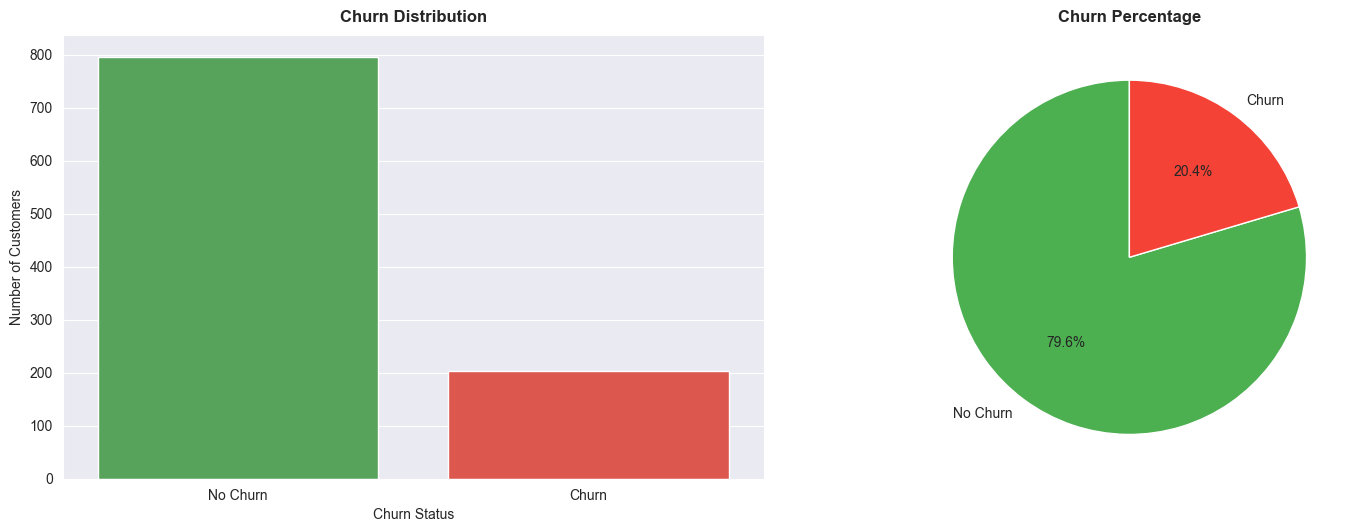

In [41]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.countplot(
    x=churn_labels,
    palette=['#4CAF50', '#F44336']
)
plt.title('Churn Distribution', fontweight='bold', pad=10)
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
sns.despine()

plt.subplot(2,2,2)
plt.pie(
    churn_percent,
    labels=churn_percent.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4CAF50', '#F44336'])
plt.title('Churn Percentage', fontweight='bold', pad=10)
sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Target(ChurnStatus)_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Numerical Feature Distribution:

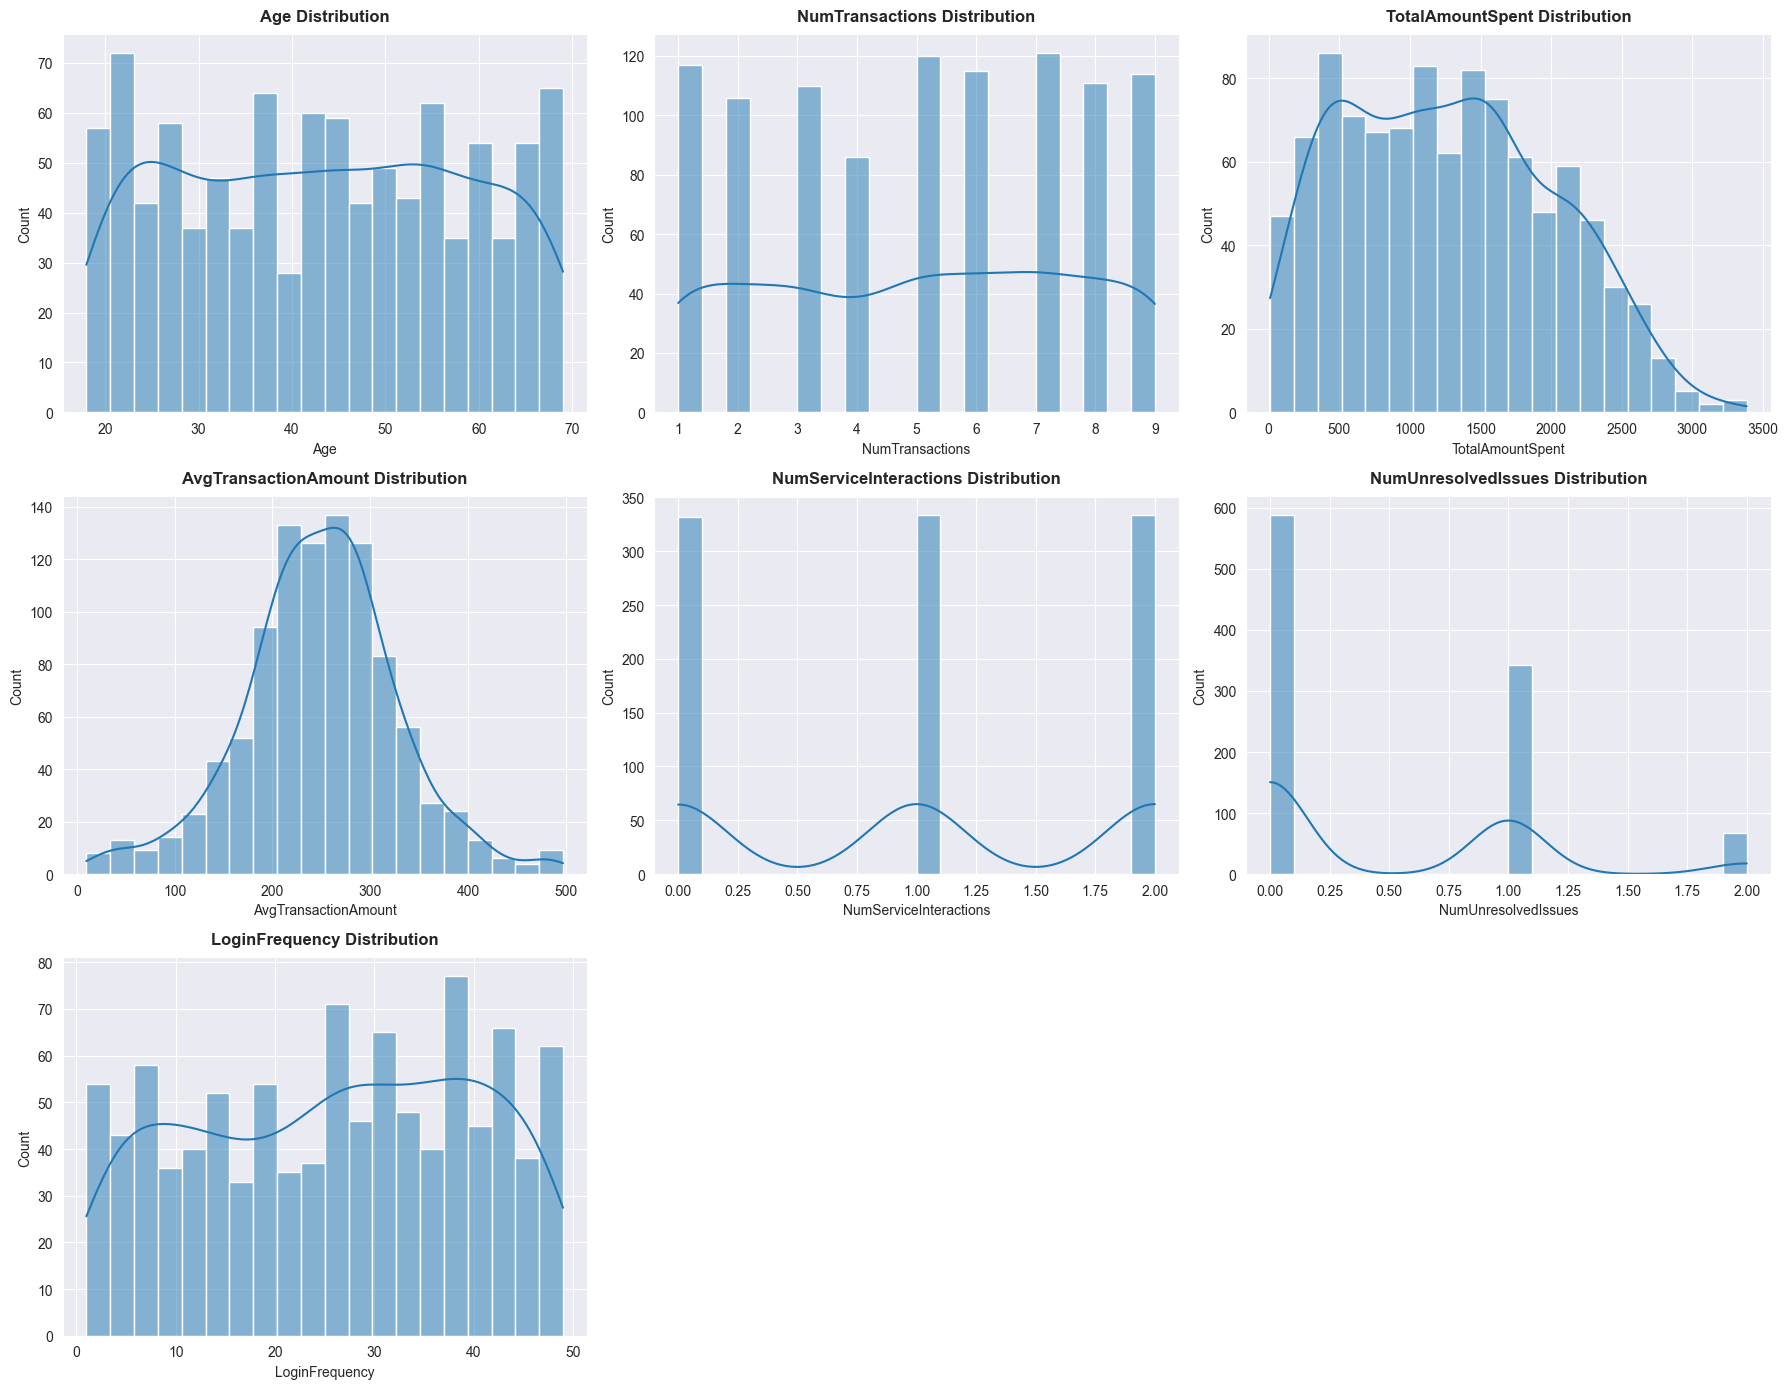

In [42]:
plt.figure(figsize=(18, 14))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)

    sns.histplot(
        data=final_df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f'{col} Distribution', fontweight='bold', pad=10)
    plt.xlabel(col)
    plt.ylabel('Count')

    sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Numerical_Feature_Distributions.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Numerical Features vs Churn:

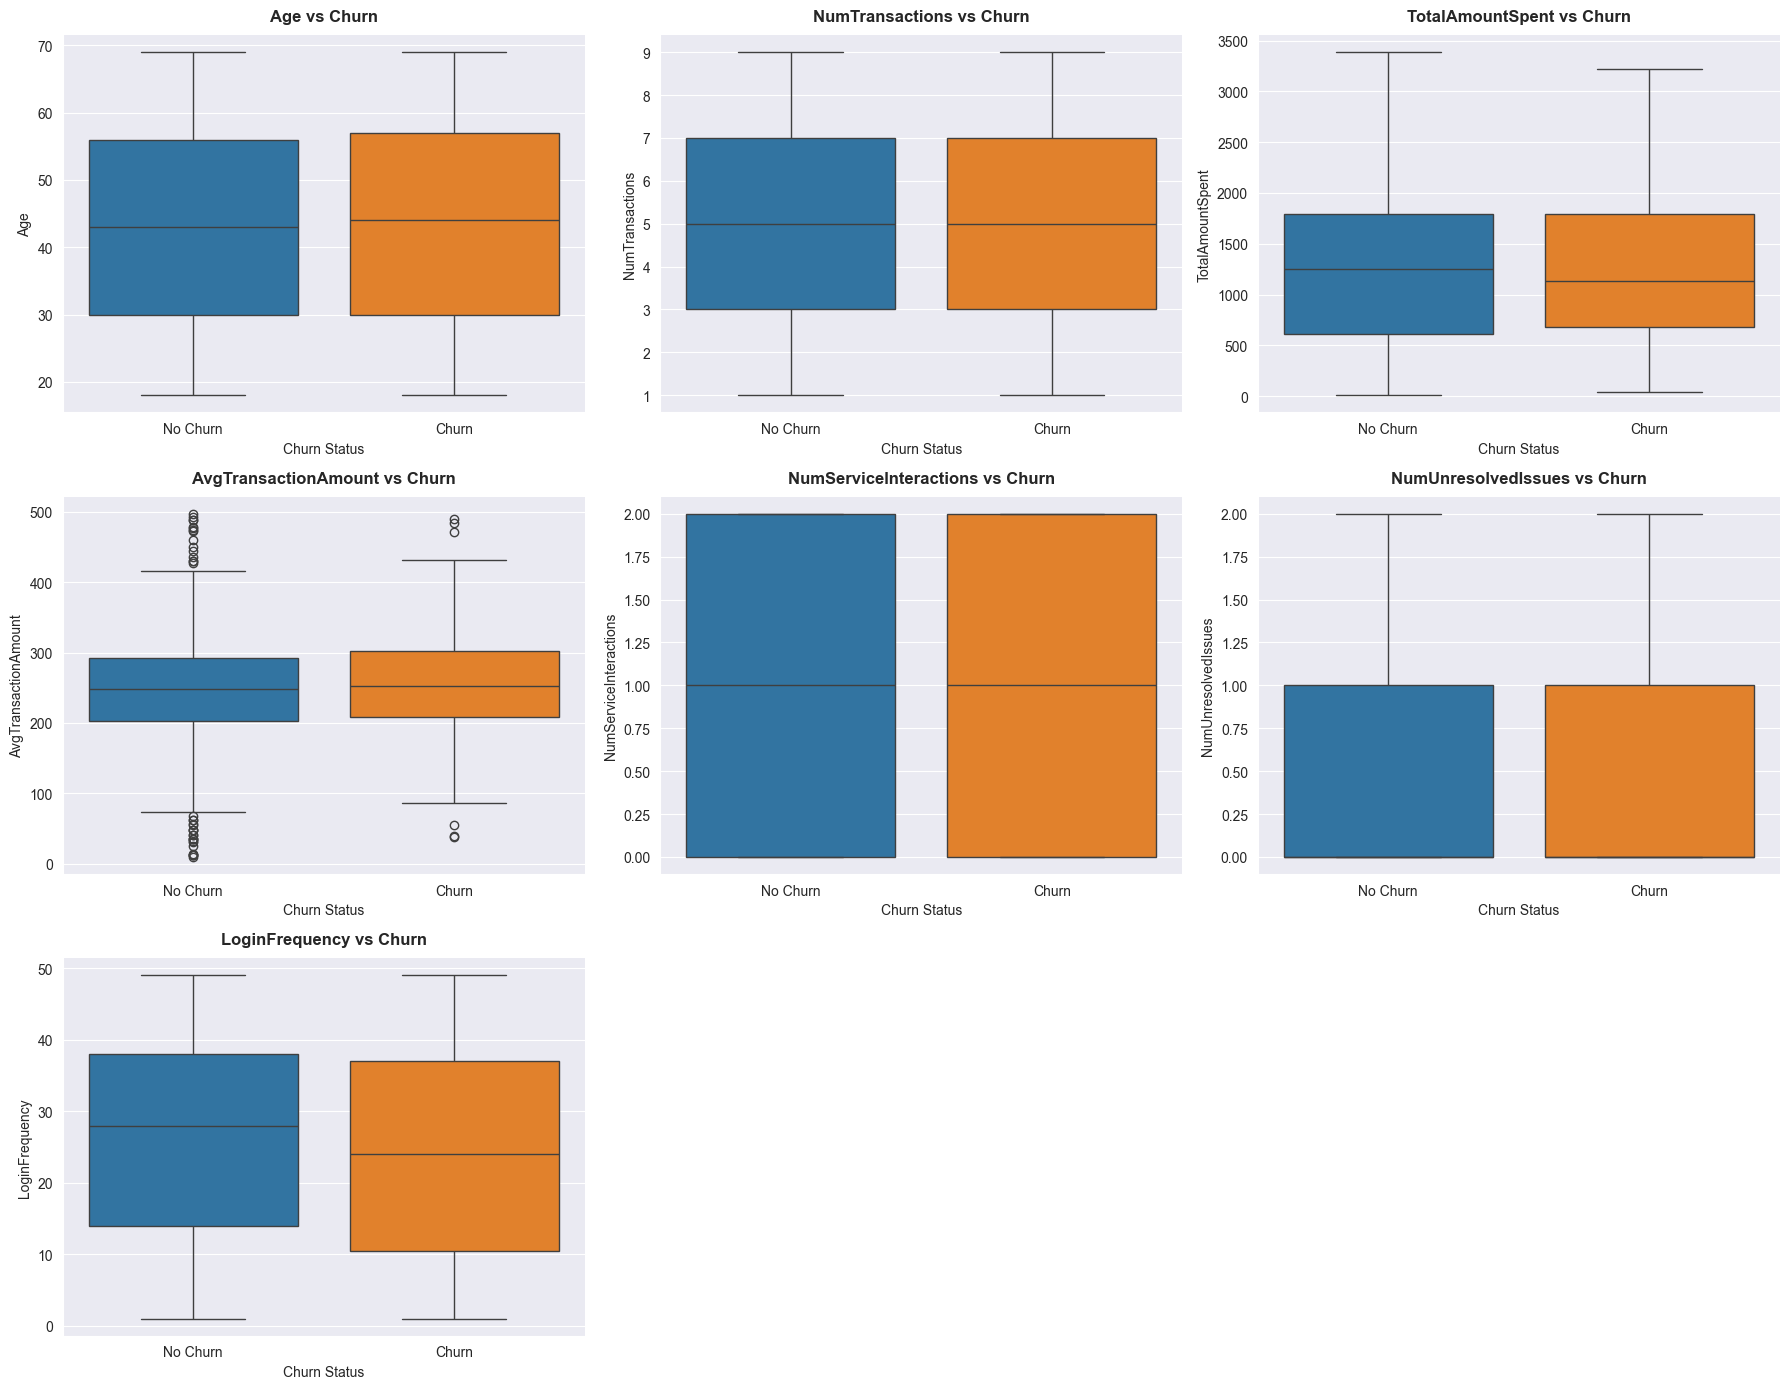

In [43]:
plt.figure(figsize=(18,14))

for i,col in enumerate(numerical_columns,1):
    plt.subplot(3,3,i)

    sns.boxplot(
        data=final_df,
        x=target_column,
        y=col,
        palette='tab10'
    )

    plt.title(f'{col} vs Churn', fontweight='bold', pad=10)
    plt.xlabel('Churn Status')
    plt.ylabel(col)
    plt.xticks([0,1],['No Churn','Churn'])
    sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Numerical_Features_vs_Churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Categorical Features vs Churn:

In [44]:
# Check churn rate by categories
for col in categorical_columns:
    churn_rate = (
        final_df.groupby(col)[target_column]
        .mean()
        .sort_values(ascending=False) * 100
    )

    print(f"\nChurn Rate by {col}")
    print(churn_rate.round(2))
    print("-"*40)


Churn Rate by Gender
Gender
M    21.15
F    19.69
Name: ChurnStatus, dtype: float64
----------------------------------------

Churn Rate by MaritalStatus
MaritalStatus
Married     22.99
Single      20.47
Widowed     19.57
Divorced    18.55
Name: ChurnStatus, dtype: float64
----------------------------------------

Churn Rate by IncomeLevel
IncomeLevel
Low       22.15
Medium    19.94
High      19.20
Name: ChurnStatus, dtype: float64
----------------------------------------

Churn Rate by ServiceUsage
ServiceUsage
Mobile App        23.10
Online Banking    20.06
Website           17.80
Name: ChurnStatus, dtype: float64
----------------------------------------


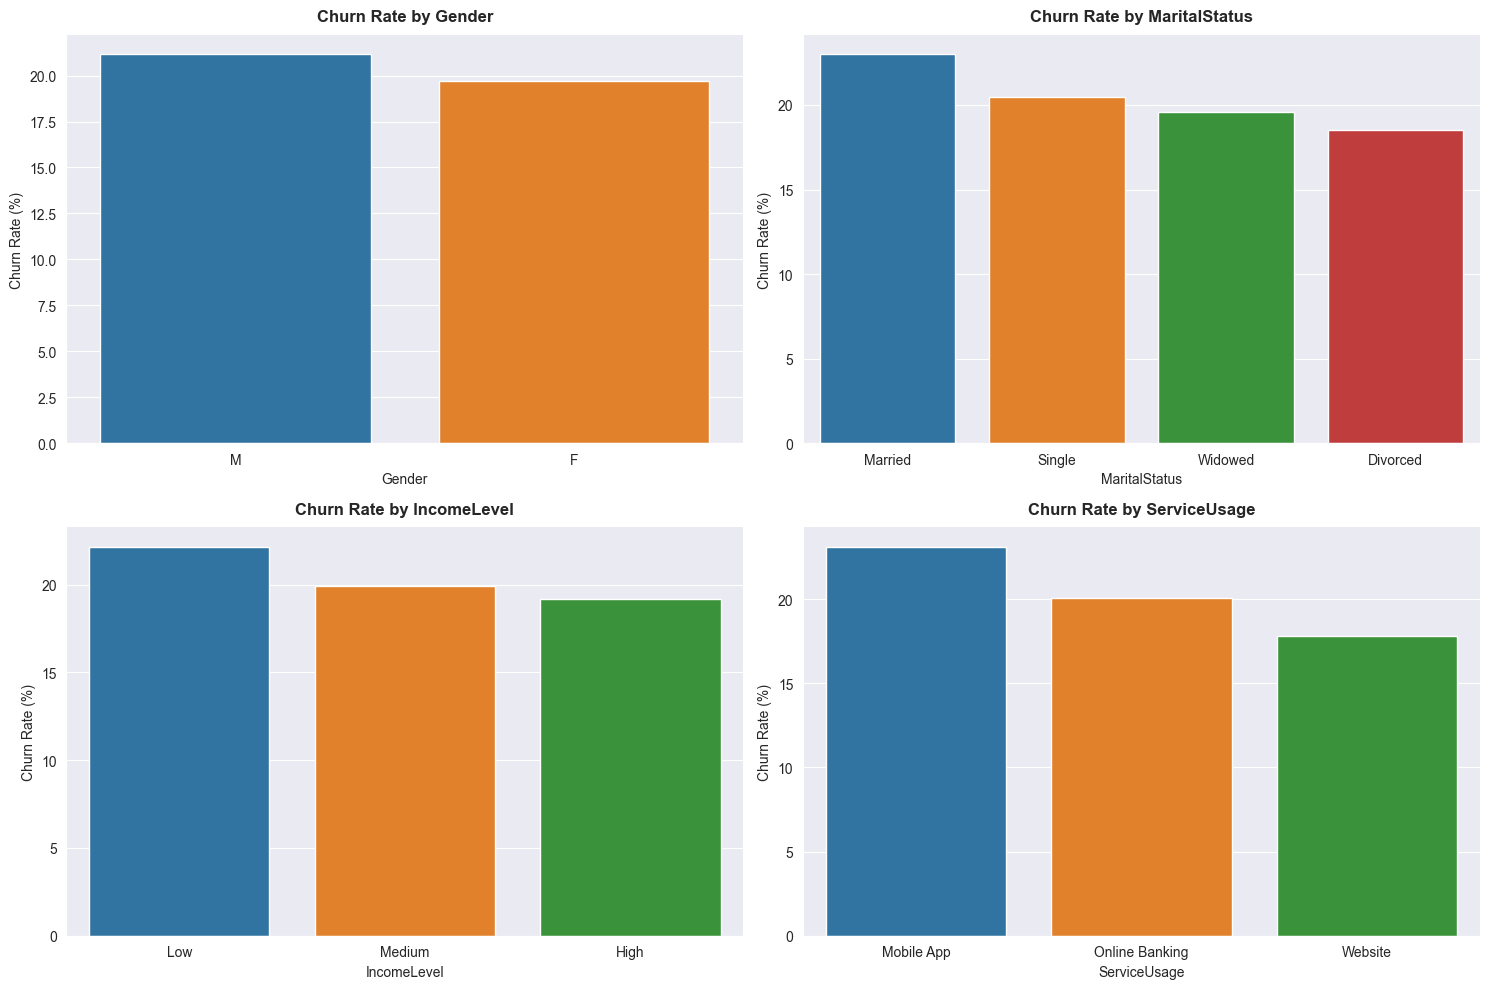

In [45]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(2, 2, i)

    churn_rate = (
        final_df.groupby(col)[target_column]
        .mean()
        .sort_values(ascending=False) * 100
    )

    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values,
        palette='tab10'
    )

    plt.title(f'Churn Rate by {col}', fontweight='bold', pad=10)
    plt.xlabel(col)
    plt.ylabel('Churn Rate (%)')
    sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Categorical_Features_vs_Churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Relationship between columns 

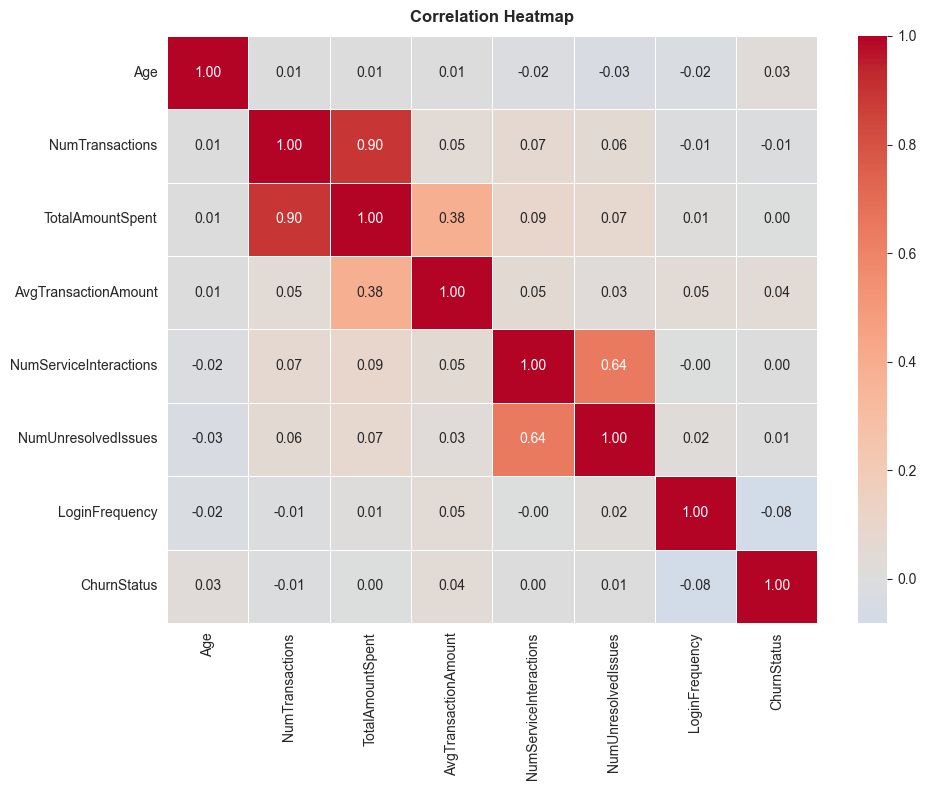

In [46]:
# Define corr_columns by adding numerical_columns and target_column 
corr_columns = numerical_columns + [target_column]

plt.figure(figsize=(10,8))
sns.heatmap(final_df[corr_columns].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold', pad=10)

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Correlation_Heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Observations:

- The final dataset contains 1000 records and 13 features after removing `CustomerID`, with no duplicate records.
- Missing values were present only in `NumServiceInteractions` and `NumUnresolvedIssues`, these were filled with 0 because they represent customers who did not contact customer service.
- The target variable is moderately imbalanced, with 79.6% of customers retained and 20.4% churned.
- Most numerical features show similar distributions across churned and non-churned customers.
- Churned customers tend to have slightly lower `LoginFrequency` and slightly higher numbers of unresolved service issues.
- Male customers, married customers, low-income customers, and mobile app users exhibit relatively higher churn rates.
- `NumTransactions` and `TotalAmountSpent` are highly correlated, while most other features show weak correlations with churn.

In [47]:
# Save data 
final_df.to_csv('../data/cleaned_customer_churn_data.csv', index=False)